# **Pakistan Economic Indicators Analysis — Exploratory Data Deep Dive 🇵🇰**

**This project presents a comprehensive Exploratory Data Analysis (EDA) on a World Bank dataset containing over 1,400 economic indicators for Pakistan from 1960 to 2024. The primary objective was to examine how key metrics including GDP growth, inflation, remittances, urbanization, and access to electricity have shaped Pakistan's economic trajectory over six decades.**

## **Goals:**

* Clean and preprocess real-world World Bank data for analysis.
* Identify key trends and turning points in Pakistan's economy.
* Visualize insights through charts using Matplotlib.
* Summarize findings with data-backed observations on Pakistan's development.

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

In [122]:
df = pd.read_csv("data/API_PAK_DS2_en_csv_v2_3387.csv",skiprows= 4)

# **Exploring Data**

In [123]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Pakistan,PAK,"Intentional homicides (per 100,000 people)",VC.IHR.PSRC.P5,NaN,NaN,NaN,NaN,NaN,NaN,...,3.688294,3.631534,3.472257,3.553165,3.786572,4.077543,4.334871,NaN,NaN,NaN
1,Pakistan,PAK,"Internally displaced persons, new displacement...",VC.IDP.NWCV,NaN,NaN,NaN,NaN,NaN,NaN,...,75000.000000,1700.000000,15000.000000,160.000000,NaN,680.000000,2800.000000,NaN,NaN,NaN
2,Pakistan,PAK,High-technology exports (% of manufactured exp...,TX.VAL.TECH.MF.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.176369,2.169753,2.302697,1.887812,1.488488,1.432256,1.902809,2.438152,NaN,NaN
3,Pakistan,PAK,Export value index (2015 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,97.600000,106.000000,105.600000,99.500000,128.200000,139.900000,128.900000,NaN,NaN,NaN
4,Pakistan,PAK,Merchandise exports to low- and middle-income ...,TX.VAL.MRCH.R6.ZS,5.68054,7.179931,7.475128,7.116744,7.250342,7.48183,...,6.061951,5.421666,5.160084,5.494221,4.311952,4.160051,5.342362,NaN,NaN,NaN


In [124]:
df.shape

(1486, 71)

In [125]:
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1486 entries, 0 to 1485
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    1486 non-null   str    
 1   Country Code    1486 non-null   str    
 2   Indicator Name  1486 non-null   str    
 3   Indicator Code  1486 non-null   str    
 4   1960            251 non-null    float64
 5   1961            288 non-null    float64
 6   1962            297 non-null    float64
 7   1963            304 non-null    float64
 8   1964            309 non-null    float64
 9   1965            313 non-null    float64
 10  1966            309 non-null    float64
 11  1967            316 non-null    float64
 12  1968            316 non-null    float64
 13  1969            321 non-null    float64
 14  1970            416 non-null    float64
 15  1971            451 non-null    float64
 16  1972            464 non-null    float64
 17  1973            444 non-null    float64
 18 

In [127]:
df.isnull().sum().sum()

np.int64(54296)

In [142]:
df["Indicator Name"].value_counts()

Indicator Name
Intentional homicides (per 100,000 people)                                                                        1
Internally displaced persons, new displacement associated with conflict and violence (number of cases)            1
High-technology exports (% of manufactured exports)                                                               1
Export value index (2015 = 100)                                                                                   1
Merchandise exports to low- and middle-income economies in Sub-Saharan Africa (% of total merchandise exports)    1
                                                                                                                 ..
Net bilateral aid flows from DAC donors, Netherlands (current US$)                                                1
Net bilateral aid flows from DAC donors, Japan (current US$)                                                      1
Net bilateral aid flows from DAC donors, Hungary (current

# **Data Filtering & Manipulation**

We narrowed down 1,400+ indicators to 9 based on data availability and relevance. These cover three key dimensions:

Economy — GDP growth, GDP per capita, inflation, and remittances.
People — Population, life expectancy, and unemployment.
Technology & Urbanization — Mobile subscriptions and urban population.

Together they paint a complete picture of Pakistan's development from 1960 to 2024.

In [128]:
indicators = [
    "GDP growth (annual %)",
    "GDP per capita (current US$)",
    "Inflation, consumer prices (annual %)",
    "Population, total",
    "Life expectancy at birth, total (years)",
    "Personal remittances, received (% of GDP)",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "Mobile cellular subscriptions (per 100 people)",
    "Urban population (% of total population)"
]

df_filtered = df[df["Indicator Name"].isin(indicators)]
df_filtered.shape

(9, 71)

In [129]:
df_long  = pd.melt(df_filtered, id_vars="Indicator Name" , var_name= "Year"   , value_name=  "Value")
df_long = df_long.dropna()
df_long = df_long[df_long["Year"].str.isnumeric()]

In [130]:
df_long["Year"] = df_long["Year"].astype(int)
df_long["Value"] = df_long["Value"].astype(float)

In [131]:
gdp_growth = df_long[df_long['Indicator Name'] == "GDP growth (annual %)"]
gdp_per_capita = df_long[df_long['Indicator Name'] == "GDP per capita (current US$)"]
inflation = df_long[df_long['Indicator Name'] == "Inflation, consumer prices (annual %)"]
population = df_long[df_long['Indicator Name'] == "Population, total"]
life_expectancy = df_long[df_long['Indicator Name'] == "Life expectancy at birth, total (years)"]
personal_remittances = df_long[df_long['Indicator Name'] == "Personal remittances, received (% of GDP)"]
unemployment = df_long[df_long['Indicator Name'] == "Unemployment, total (% of total labor force) (modeled ILO estimate)"]
mobile_subs = df_long[df_long['Indicator Name'] == "Mobile cellular subscriptions (per 100 people)"]
urban_population = df_long[df_long['Indicator Name'] == "Urban population (% of total population)"]

# **Correlation Analysis**

In [132]:
pivot_df = df_long.pivot(index="Year", columns="Indicator Name", values="Value")
correlation = pivot_df.corr()
correlation

Indicator Name,GDP growth (annual %),GDP per capita (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Mobile cellular subscriptions (per 100 people),"Personal remittances, received (% of GDP)","Population, total","Unemployment, total (% of total labor force) (modeled ILO estimate)",Urban population (% of total population)
Indicator Name,,,,,,,,,
GDP growth (annual %),1.000000,-0.340773,-0.293453,-0.369844,-0.404179,0.157197,-0.422126,-0.206275,-0.416651
GDP per capita (current US$),-0.340773,1.000000,0.199988,0.851132,0.947610,0.224415,0.966012,0.791239,0.912639
"Inflation, consumer prices (annual %)",-0.293453,0.199988,1.000000,0.281665,0.314074,0.138179,0.237603,0.257481,0.262280
"Life expectancy at birth, total (years)",-0.369844,0.851132,0.281665,1.000000,0.736544,0.075819,0.925434,0.790717,0.973910
Mobile cellular subscriptions (per 100 people),-0.404179,0.947610,0.314074,0.736544,1.000000,0.392306,0.876149,0.827253,0.801306
"Personal remittances, received (% of GDP)",0.157197,0.224415,0.138179,0.075819,0.392306,1.000000,0.061644,0.904451,0.041667
"Population, total",-0.422126,0.966012,0.237603,0.925434,0.876149,0.061644,1.000000,0.827965,0.979636
"Unemployment, total (% of total labor force) (modeled ILO estimate)",-0.206275,0.791239,0.257481,0.790717,0.827253,0.904451,0.827965,1.000000,0.873668
Urban population (% of total population),-0.416651,0.912639,0.262280,0.973910,0.801306,0.041667,0.979636,0.873668,1.000000


# **Data Analysis**

### GDP Growth Trend

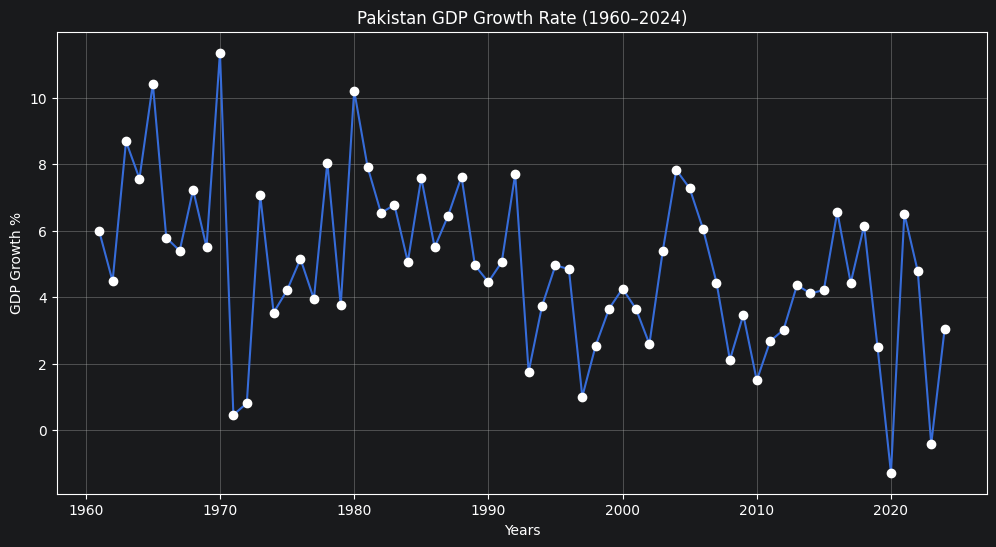

In [133]:
plt.figure(figsize=(12,6))
plt.plot(gdp_growth["Year"],gdp_growth["Value"], marker = "o" , mfc = "white" , mec = "white" )
plt.title("Pakistan GDP Growth Rate (1960–2024)")
plt.xlabel("Years")
plt.ylabel("GDP Growth %")
plt.grid()
plt.show()

### Highest & Lowest Inflation years

In [134]:
max_inflation = inflation.loc[inflation["Value"].idxmax()]
min_inflation = inflation.loc[inflation["Value"].idxmin()]
print(max_inflation)
print(min_inflation)

Indicator Name    Inflation, consumer prices (annual %)
Year                                               2023
Value                                         30.768128
Name: 601, dtype: object
Indicator Name    Inflation, consumer prices (annual %)
Year                                               1962
Value                                         -0.516462
Name: 52, dtype: object


### Inflation Trend

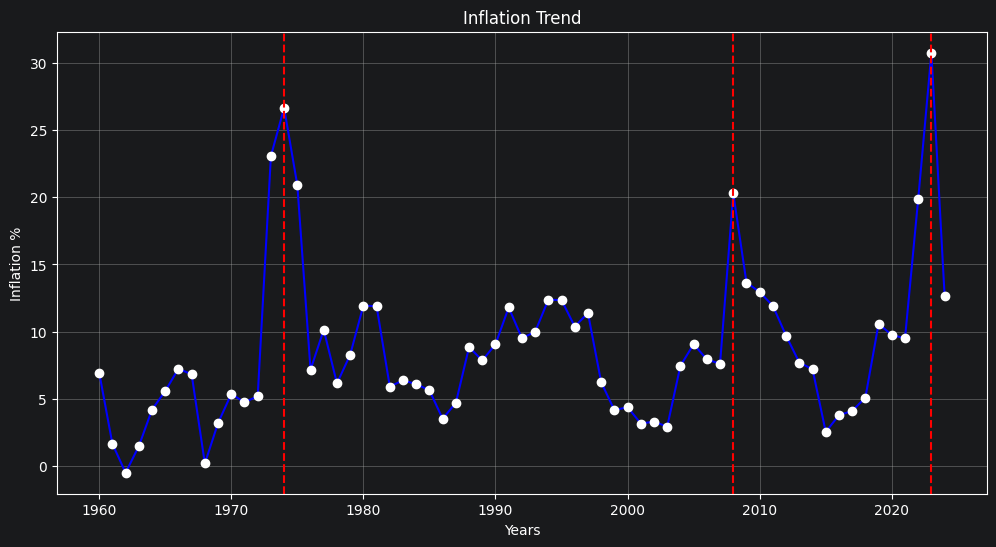

In [135]:
plt.figure(figsize= (12,6))
plt.plot(inflation["Year"], inflation["Value"] ,color = "blue" , marker = "o", mfc = "white" , mec = "white")
plt.title("Inflation Trend")
plt.xlabel("Years")
plt.ylabel("Inflation %")
spikes = [1974, 2008, 2023]
for year in spikes:
    plt.axvline(x=year, color="red", linestyle="--")
plt.grid()
plt.show()

### Population Growth

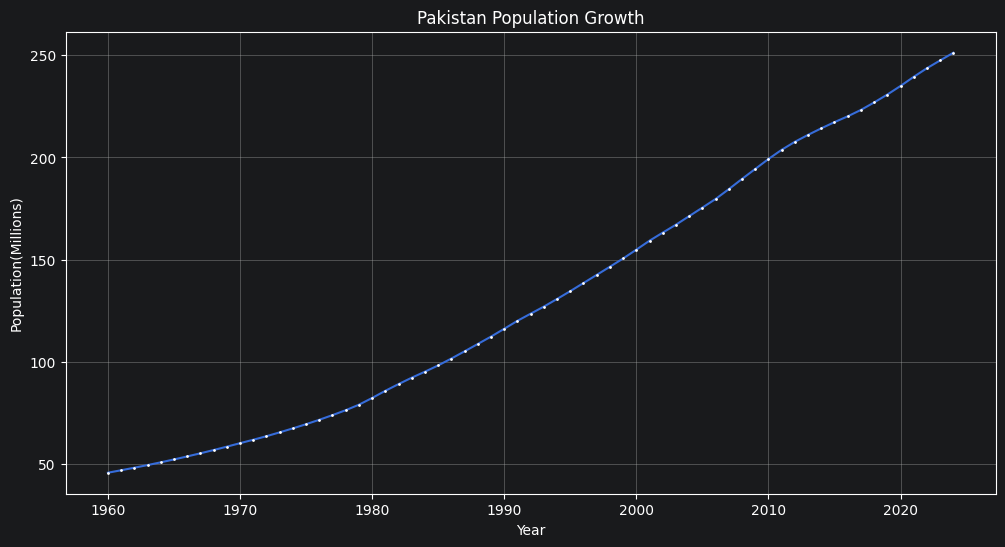

In [136]:
plt.figure(figsize=(12,6))
plt.plot(population["Year"] , population["Value"] / 1000000, marker = "." , mfc = "white" , mec="white", markersize = 2)
plt.title("Pakistan Population Growth")
plt.xlabel("Year")
plt.ylabel("Population(Millions)")
plt.grid()
plt.show()

### GDP Growth vs Inflation

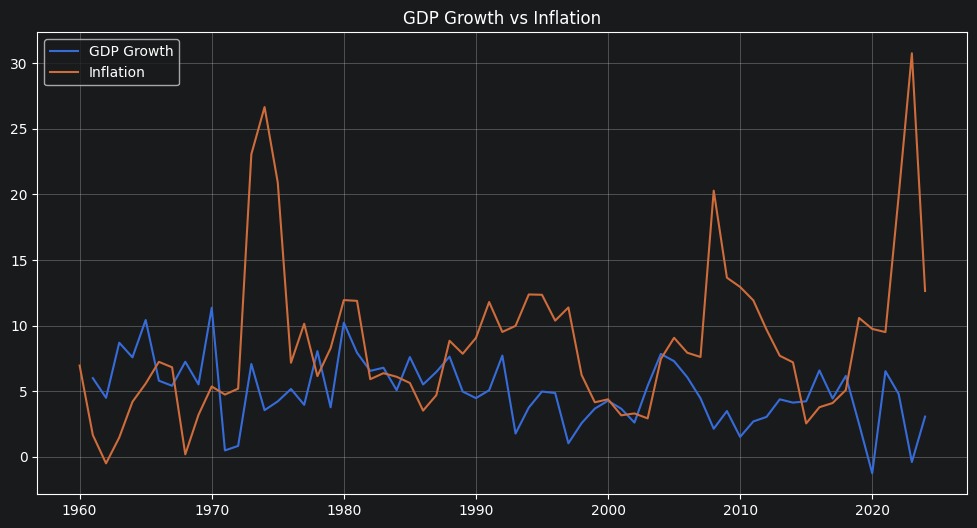

In [137]:
plt.figure(figsize=(12,6))
plt.plot(gdp_growth["Year"],gdp_growth["Value"],label="GDP Growth")
plt.plot(inflation["Year"],inflation["Value"],label="Inflation")
plt.legend()
plt.title("GDP Growth vs Inflation")
plt.grid()
plt.show()

### Population vs Urbanization

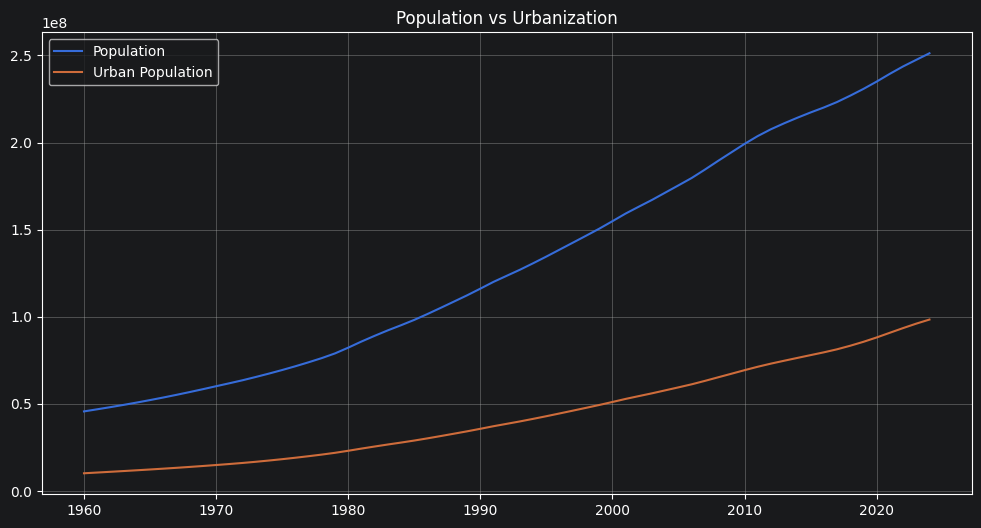

In [138]:
plt.figure(figsize=(12,6))
plt.plot(population["Year"],population["Value"],label="Population")
plt.plot(urban_population["Year"], population["Value"].values * urban_population["Value"].values / 100, label="Urban Population")
plt.legend()
plt.title("Population vs Urbanization")
plt.grid()
plt.show()

# Key Findings

* Pakistan recorded its highest GDP growth in 1970 at over 10%, but long-term trends show increasing economic volatility and slower average growth in recent decades.
* Pakistan experienced its highest inflation in 2023 (30.7%) and one of its lowest inflation periods in 1960. Major inflation spikes occurred in 1974, 2008, and 2023, corresponding to global oil shocks, the global financial crisis, currency depreciation, and domestic political instability.
* Pakistan’s total population has grown rapidly since 1960, while urbanization has increased at a slower pace, indicating that a significant portion of population growth still occurs in rural regions.
* Inflation trends generally rise during periods of weaker GDP growth, suggesting stagflation-like economic pressures in several periods of Pakistan’s economic history.
* GDP per capita shows a very strong positive correlation with mobile cellular subscriptions, suggesting that rising income levels are associated with increased technology adoption.
* Urbanization strongly correlates with life expectancy, indicating that improved healthcare access, infrastructure, and living conditions in urban areas may contribute to longer average lifespans.
* Inflation demonstrates a negative relationship with GDP growth, where periods of high inflation often coincide with slower economic expansion.
* Remittances show a strong positive correlation with unemployment, suggesting that overseas employment becomes increasingly important during periods of weaker domestic labor market conditions.
* Pakistan’s GDP per capita crossed approximately $1000 around 2006 but has struggled to maintain sustained high-income growth, reflecting long-term structural and economic challenges.